# 📊 Pipeline de Análise dos Logs da Plataforma
Este notebook realiza uma leitura, inspeção e visualização inicial dos logs da plataforma de ingressos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import sqlite3
import pandas as pd

# Conectar ao banco e identificar as tabelas
con = sqlite3.connect("../database.db")
cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tabelas = [t[0] for t in cursor.fetchall()]
print("Tabelas disponíveis:", tabelas)

# Se existir a tabela 'logs', prossegue com a análise
if 'logs' in tabelas:
    logs = pd.read_sql_query("SELECT * FROM logs", con)
    logs['data_hora'] = pd.to_datetime(logs['data_hora'])

    def describe_completo(df):
        resumo = {}

        # Descrição geral
        resumo['describe_padrao'] = df.describe(include='all')

        # Valores ausentes
        resumo['valores_ausentes'] = df.isnull().sum()

        # Estatísticas de tempo
        if 'data_hora' in df.columns:
            duracao_total = df['data_hora'].max() - df['data_hora'].min()
            intervalo_medio = duracao_total / len(df)
            resumo['tempo_total'] = duracao_total
            resumo['intervalo_medio'] = intervalo_medio

        # Estatísticas de colunas categóricas
        for col in df.select_dtypes(include='object').columns:
            resumo[f'unicos_{col}'] = df[col].nunique()
            resumo[f'frequencia_{col}'] = df[col].value_counts()

        return resumo

    relatorio_logs = describe_completo(logs)

else:
    relatorio_logs = f"Tabela 'logs' não encontrada. Tabelas disponíveis: {tabelas}"

relatorio_logs



Tabelas disponíveis: ['usuarios', 'sqlite_sequence', 'ingressos', 'logs']


{'describe_padrao':                id  usuario                           acao  \
 count   27.000000       27                             27   
 unique        NaN        3                              3   
 top           NaN  Teodoro  Comprou ingresso para: Show A   
 freq          NaN       21                             13   
 mean    14.000000      NaN                            NaN   
 min      1.000000      NaN                            NaN   
 25%      7.500000      NaN                            NaN   
 50%     14.000000      NaN                            NaN   
 75%     20.500000      NaN                            NaN   
 max     27.000000      NaN                            NaN   
 std      7.937254      NaN                            NaN   
 
                             data_hora  
 count                              27  
 unique                            NaN  
 top                               NaN  
 freq                              NaN  
 mean    2025-05-19 17:02:07.4

In [3]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         27 non-null     int64         
 1   usuario    27 non-null     object        
 2   acao       27 non-null     object        
 3   data_hora  27 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 996.0+ bytes


In [4]:
logs.describe(include='all')

,id,usuario,acao,data_hora
count,27.000000,27,27,27
unique,NaN,3,3,NaN
top,NaN,Teodoro,Comprou ingresso para: Show A,NaN
freq,NaN,21,13,NaN
mean,14.000000,NaN,NaN,2025-05-19 17:02:07.444444416
min,1.000000,NaN,NaN,2025-05-19 16:24:46
25%,7.500000,NaN,NaN,2025-05-19 16:27:50.500000
50%,14.000000,NaN,NaN,2025-05-19 16:28:17
75%,20.500000,NaN,NaN,2025-05-19 16:30:31
max,27.000000,NaN,NaN,2025-05-19 19:03:05


## 🔍 Visualização de Distribuições

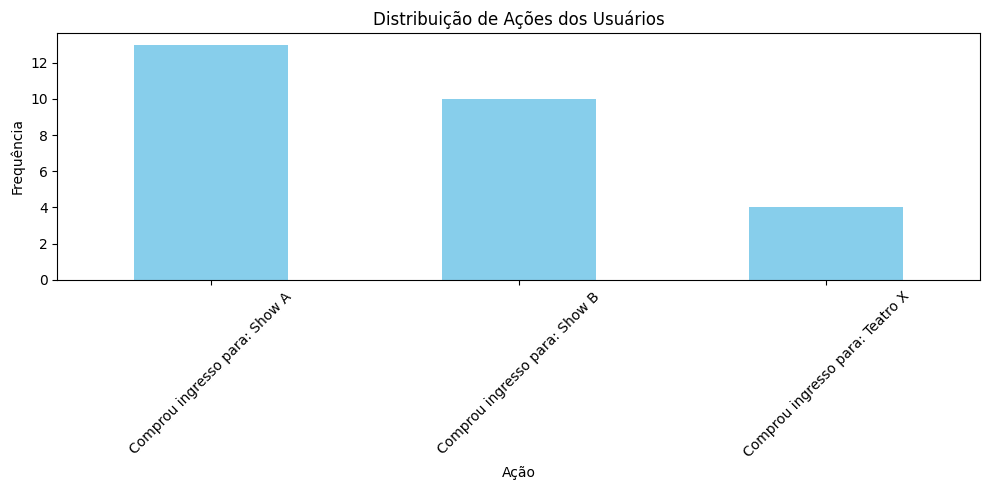

In [5]:
plt.figure(figsize=(10, 5))
logs['acao'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribuição de Ações dos Usuários')
plt.xlabel('Ação')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\vitor\AppData\Local\Temp\ipykernel_32032\504643709.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  logs.set_index('data_hora').resample('H').size().plot(figsize=(12, 5))  # por hora


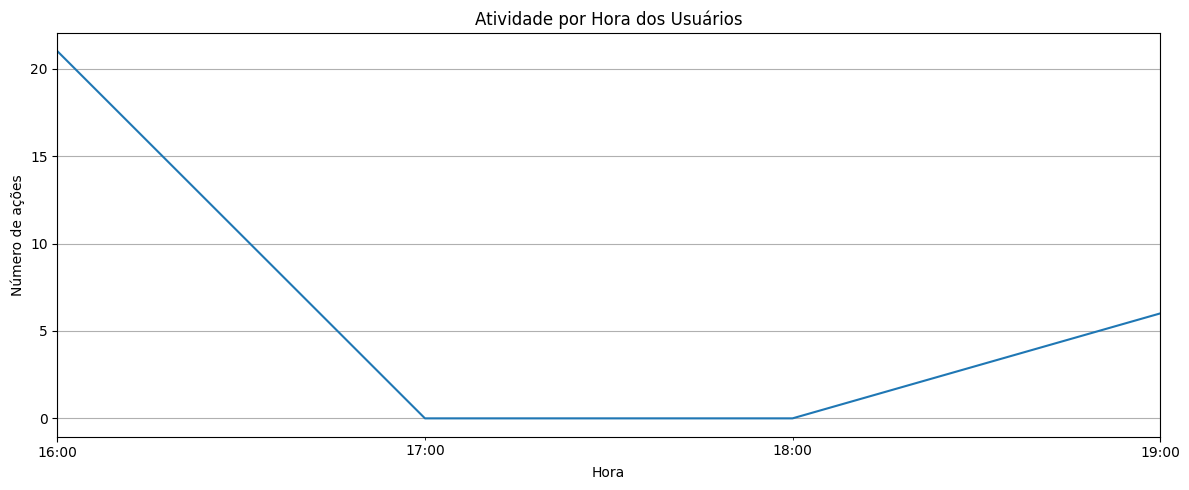

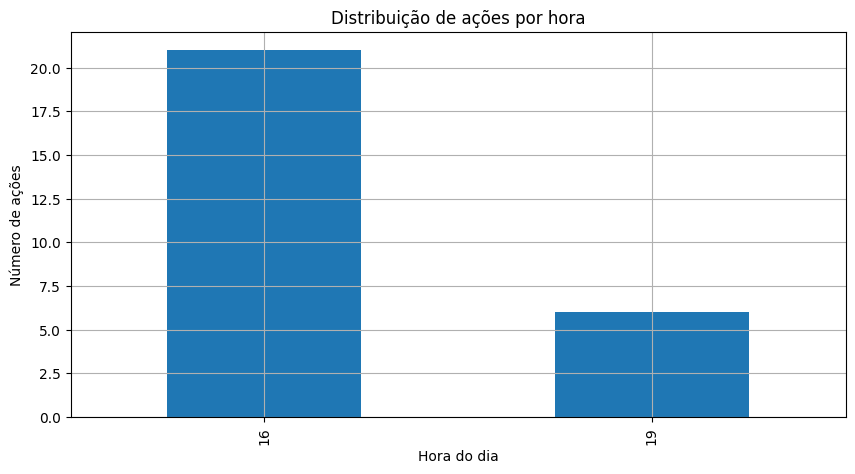

In [6]:
logs['hora'] = logs['data_hora'].dt.hour
logs['hora'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title('Distribuição de ações por hora')
plt.xlabel('Hora do dia')
plt.ylabel('Número de ações')
plt.grid(True)
plt.show()
